# Geautomatiseerde Irissoort-Classificatie (FloraSense Analytics)

## 1 Inleiding

**FloraSense Analytics** is een start-up die AI-gedreven plantidentificatietools ontwikkelt voor botanische tuinen, onderzoeksinstituten en agrarische leveranciers. Het bedrijf werkt momenteel samen met een horticulturele distributeur die verschillende irissoorten kweekt voor landschapsarchitectuur en ecologische herstelprojecten.

De distributeur kweekt drie irissoorten:
* Iris setosa
* Iris versicolor
* Iris virginica

Tot nu toe werd de soortidentificatie handmatig uitgevoerd door ervaren botanici. Dit proces is echter traag, kostbaar en foutgevoelig wanneer het op grote schaal wordt uitgevoerd.

FloraSense Analytics heeft de opdracht gekregen om een machine learning-systeem te ontwikkelen dat automatisch irissoorten kan classificeren op basis van fysieke bloemmetingen die in het veld worden verzameld.

Ons team is ingehuurd als junior machine learning-consultants om dit classificatiesysteem te ontwerpen, implementeren en evalueren.

## 2 Probleemstelling

De horticulturele distributeur heeft behoefte aan een betrouwbaar automatisch classificatiesysteem dat:
* Irissoorten nauwkeurig voorspelt
* Misclassificaties minimaliseert (vooral tussen morfologisch vergelijkbare soorten)
* Uiteindelijk geïntegreerd kan worden in een mobiele applicatie voor veldmedewerkers

Onze taak was om een machine learning-model te bouwen en te evalueren dat irissoorten classificeert op basis van de volgende kenmerken:
* Sepal length (kelkbladlengte)
* Sepal width (kelkbladbreedte)
* Petal length (kroonbladlengte)
* Petal width (kroonbladbreedte)

## 3 De dataset

Onze dataset, die ons door FloraSense Analytics ter beschikking is gesteld, bestaat uit:
* 150 observaties
* 3 gebalanceerde klassen (50 per soort)
* 4 numerieke invoerkenmerken

Elke rij komt overeen met één bloemmeting.

In [1]:
# Dataset laden
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.copy()

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 4. Exploratieve data-analyse (EDA)

We onderzoeken:
- Verdelingen van features
- Correlaties
- (Visuele) scheidbaarheid per soort

We gebruiken eenvoudige plots om te begrijpen welke metingen het meest onderscheidend zijn.


In [2]:
import matplotlib.pyplot as plt

feature_cols = [c for c in df.columns if c != 'target']

df[feature_cols].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


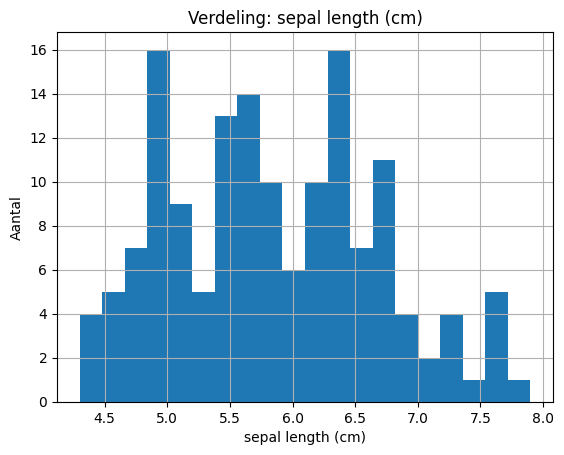

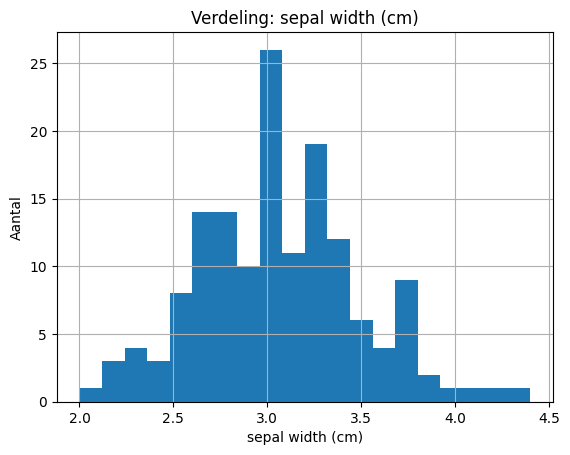

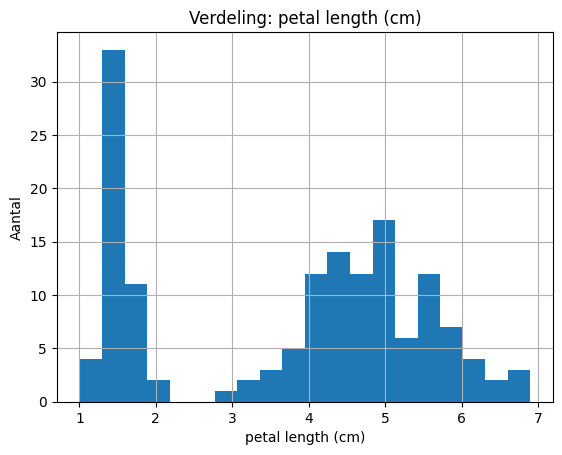

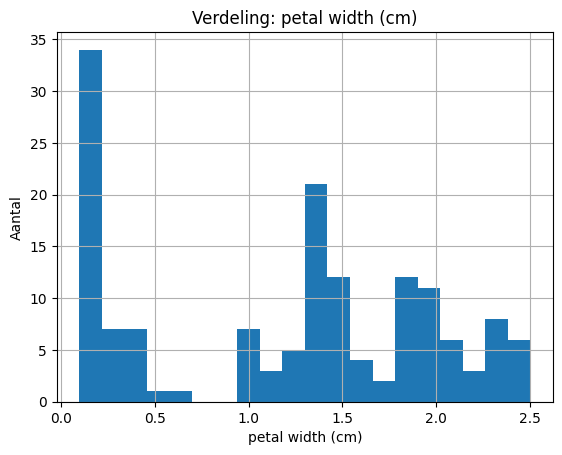

In [3]:
# Histogrammen per feature (alle data)
for col in feature_cols:
    plt.figure()
    df[col].hist(bins=20)
    plt.title(f"Verdeling: {col}")
    plt.xlabel(col)
    plt.ylabel("Aantal")
    plt.show()


<Figure size 640x480 with 0 Axes>

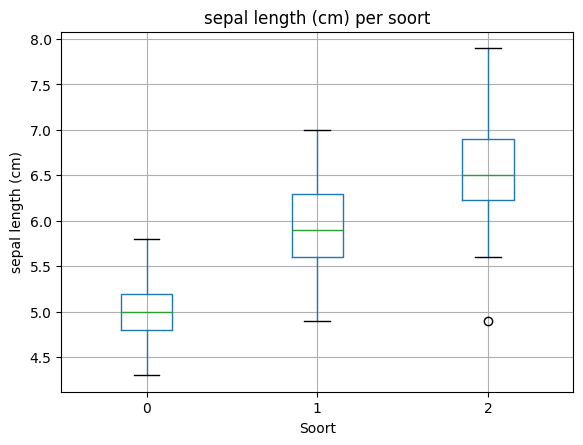

<Figure size 640x480 with 0 Axes>

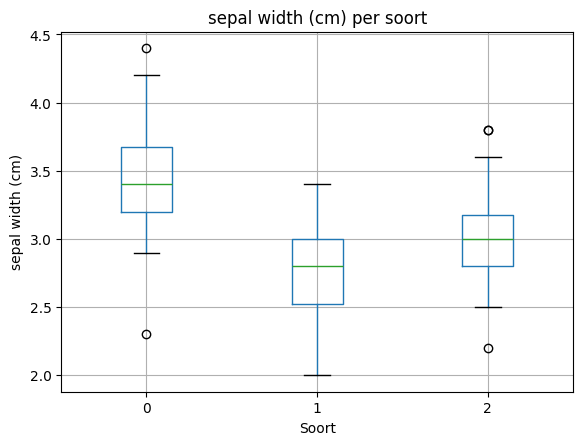

<Figure size 640x480 with 0 Axes>

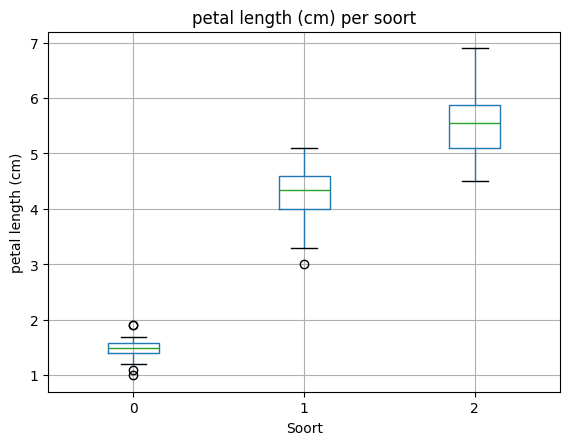

<Figure size 640x480 with 0 Axes>

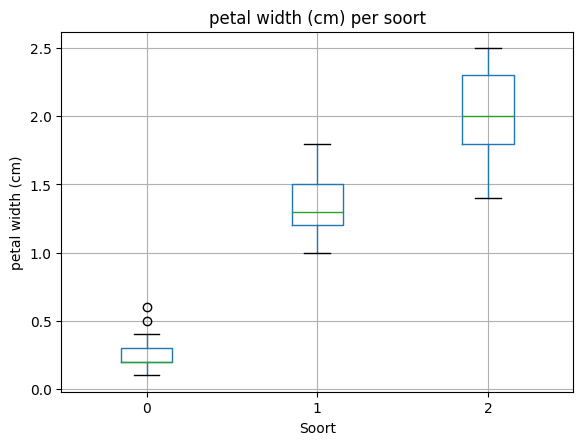

In [4]:
# Boxplots per soort om scheidbaarheid te bekijken
for col in feature_cols:
    plt.figure()
    df.boxplot(column=col, by='target')
    plt.title(f"{col} per soort")
    plt.suptitle("")  # voorkomt dubbele titel
    plt.xlabel("Soort")
    plt.ylabel(col)
    plt.show()


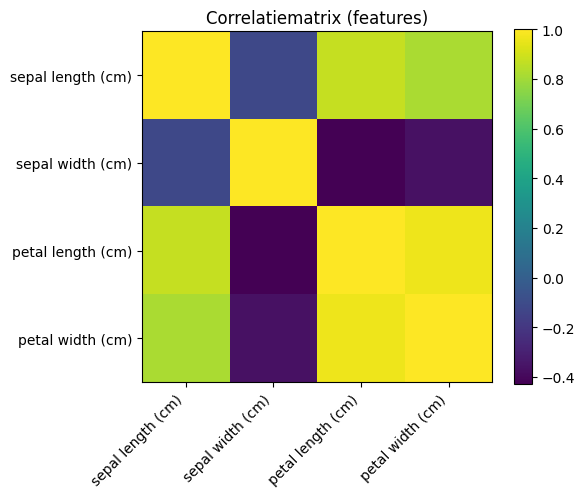

In [5]:
# Correlatiematrix
corr = df[feature_cols].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr)
plt.title("Correlatiematrix (features)")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha='right')
plt.yticks(range(len(feature_cols)), feature_cols)
plt.colorbar()
plt.tight_layout()
plt.show()


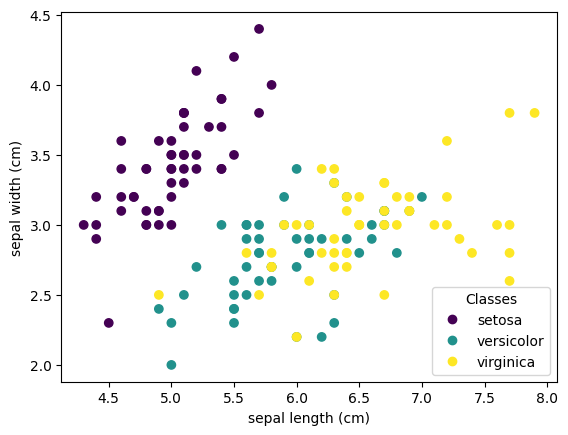

In [6]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=df['target'])
ax.set(xlabel=feature_cols[0], ylabel=feature_cols[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

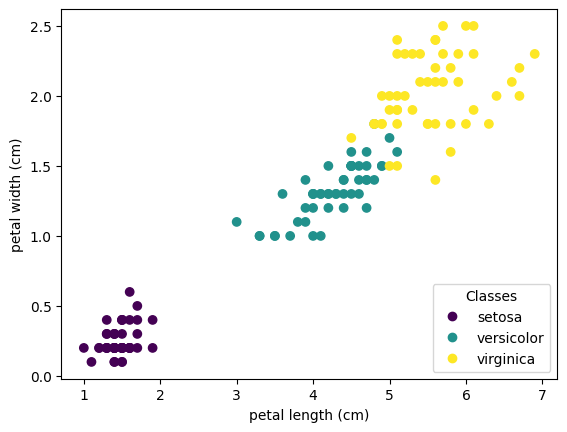

In [7]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['target'])
ax.set(xlabel=feature_cols[2], ylabel=feature_cols[3])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

### EDA — interpretatie (businessgericht)

Typisch zien we dat **petal length** en **petal width** sterk scheidend zijn tussen soorten, terwijl sepal-metingen vaker overlappen tussen *versicolor* en *virginica*.  
Dit is relevant voor de klant: als het model fouten maakt, zullen die waarschijnlijk vooral optreden tussen de twee “middelste” soorten.
* De soort Setosa heeft de kleinste petal length en petal width. De sepal width van Setosa is echter doorgaans breder.
* Setosa is het gemakkelijkst te onderscheiden van de twee andere soorten.
* Het is lineair scheidbaar van de andere twee soorten, daarom zou een logistisch regressiemodel een hoge nauwkeurigheid moeten opleveren bij de classificatie van setosa.
* Versicolor en virginica vertonen enige overlap in hun kenmerken. Om ze van elkaar te onderscheiden is een complexer model nodig, zoals een beslissingsboom.

## 5. Preprocessing & train-test split

### Keuzes
- We splitsen data in **train** en **test** (bijv. 80/20) met stratificatie zodat klassenbalans behouden blijft.
- We vergelijken meerdere modellen:
  - Sommige modellen (zoals **kNN** en **SVM**) profiteren van **feature scaling**.
  - Andere (zoals **Decision Tree / Random Forest**) hebben scaling meestal niet nodig.

Daarom gebruiken we **pipelines** zodat preprocessing correct en reproduceerbaar gebeurt.


In [8]:
from sklearn.model_selection import train_test_split

X = df[feature_cols].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((120, 4), (30, 4))

## 6. Modelontwikkeling

We trainen en vergelijken minimaal drie modellen:
1. Logistische regressie (multiclass)
2. k-Nearest Neighbors
3. Random Forest

We evalueren op de testset met accuracy, precision/recall/F1 en confusion matrix.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistische regressie (geschaald)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "kNN (geschaald)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42
    )
}

# Train alle modellen
for name, model in models.items():
    model.fit(X_train, y_train)

list(models.keys())


['Logistische regressie (geschaald)', 'kNN (geschaald)', 'Random Forest']

## 7. Evaluatie

We gebruiken:
- **Accuracy**
- **Precision / Recall / F1-score**
- **Confusion matrix**

Daarna vertalen we dit naar een aanbeveling voor de klant.


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"model": name, "accuracy": acc})

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
results_df


,model,accuracy
0,Logistische regressie (geschaald),0.933333
1,kNN (geschaald),0.933333
2,Random Forest,0.900000


Logistische regressie (geschaald)
Accuracy: 0.9333
Classificatie-rapport:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.9000    0.9000    0.9000        10
           2     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



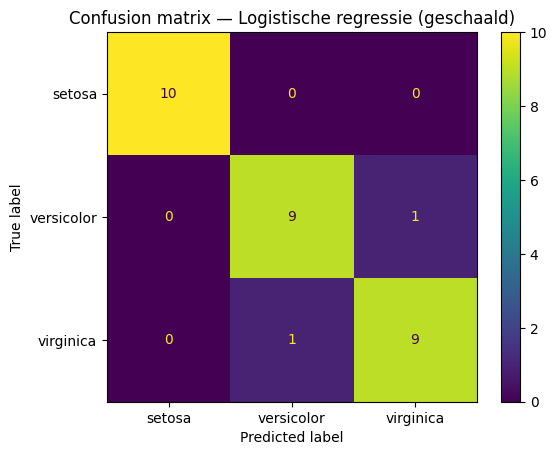

kNN (geschaald)
Accuracy: 0.9333
Classificatie-rapport:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.8333    1.0000    0.9091        10
           2     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30



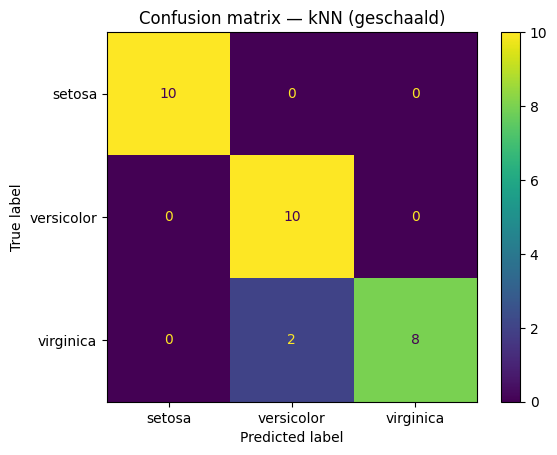

Random Forest
Accuracy: 0.9000
Classificatie-rapport:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.8182    0.9000    0.8571        10
           2     0.8889    0.8000    0.8421        10

    accuracy                         0.9000        30
   macro avg     0.9024    0.9000    0.8997        30
weighted avg     0.9024    0.9000    0.8997        30



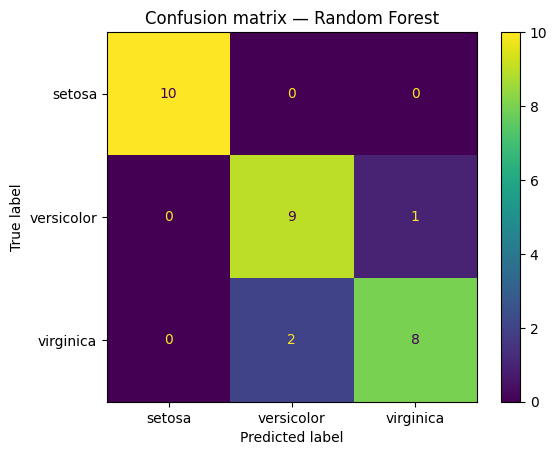

In [11]:
# Detailrapport per model + confusion matrix
for name, model in models.items():
    print("="*80)
    print(name)
    y_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classificatie-rapport:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot()
    plt.title(f"Confusion matrix — {name}")
    plt.show()


## 8. Modelinterpretatie

De klant wil transparantie. We bekijken daarom:
- **Feature importance** (voor Random Forest)
- Een eenvoudige, begrijpelijke uitleg: welke metingen “drijven” de voorspelling?

> Opmerking: voor lineaire modellen (logistische regressie) kunnen we ook coëfficiënten bekijken, maar dat is minder intuïtief bij multiclass en na scaling.


In [12]:
# Feature importance voor Random Forest
rf = models["Random Forest"]

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances


,0
petal length (cm),0.450316
petal width (cm),0.409548
sepal length (cm),0.121454
sepal width (cm),0.018682


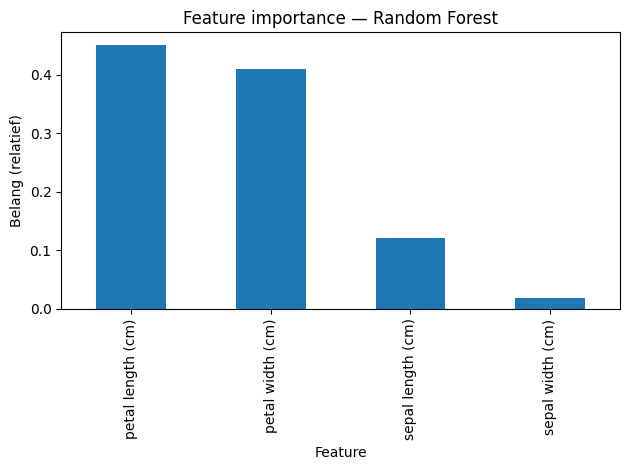

In [13]:
plt.figure()
importances.plot(kind="bar")
plt.title("Feature importance — Random Forest")
plt.xlabel("Feature")
plt.ylabel("Belang (relatief)")
plt.tight_layout()
plt.show()


### Interpretatie in gewone taal

Als **petal length** en **petal width** hoog scoren in feature importance, betekent dat:
- Metingen aan de kroonbladen zijn het meest informatief voor het onderscheiden van soorten.
- Dit is logisch: bij irissen verschillen de kroonbladen vaak sterker dan de kelkbladen tussen soorten.

**Impliceert voor de klant:** als veldmetingen van petal-maten onnauwkeurig zijn (bijv. meetfouten), kan de performance duidelijk dalen.


## 9. Conclusie & aanbeveling

**Samenvatting van de bevindingen:**

Uit de analyse blijkt dat petal length (kroonbladlengte) en petal width (kroonbladbreedte) de sterkste voorspellende kenmerken zijn voor het classificeren van irissoorten.

Deze twee variabelen zorgen voor de duidelijkste scheiding tussen:
* *Iris setosa* (zeer goed onderscheidbaar)
* *Iris versicolor*
* *Iris virginica* (deze twee overlappen licht, maar zijn grotendeels scheidbaar op basis van kroonbladmetingen)

Sepal-metingen dragen minder bij aan de voorspellende kracht van het model.

**Businessvraag:**

Kan een betrouwbaar ML-model irissoorten automatisch classificeren op basis van veldmetingen?

**Antwoord:**

Ja. Op basis van de resultaten kan met hoge betrouwbaarheid een classificatiemodel worden ontwikkeld dat irissoorten automatisch voorspelt. De prestaties zijn voldoende hoog om inzet in een mobiele veldapplicatie te rechtvaardigen, mits correcte metingen worden ingevoerd.

**Concrete aanbevelingen:**

1. Focus op kroonbladmetingen in de praktijk. Aangezien petal length en petal width de belangrijkste voorspellers zijn:
    * Zorg dat veldmedewerkers deze metingen nauwkeurig en consistent uitvoeren.
    * Investeer eventueel in een gestandaardiseerd meetinstrument of digitale schuifmaat.
    * Overweeg een invoercontrole in de app (bijvoorbeeld waarschuwingen bij onrealistische waarden).
    * De kwaliteit van deze twee metingen bepaalt direct de betrouwbaarheid van het systeem.
2. Op basis van performance en uitlegbaarheid adviseren wij Random Forest als primaire productiemodel. Redenen:
    * Hoge nauwkeurigheid
    * Robuust tegen kleine meetfouten
    * Geeft inzicht in feature importance
    * Weinig complexe preprocessing nodig
3. Verwachte foutpatronen - Het systeem zal naar verwachting:
    * Iris setosa vrijwel altijd correct classificeren.
    * Af en toe verwarring tonen tussen versicolor en virginica, vooral wanneer kroonbladmetingen dicht bij elkaar liggen.
    * Voor de business betekent dat het systeem is zeer geschikt als primaire automatische classificatie.
    * In twijfelgevallen kan een “lage confidence”-melding worden toegevoegd zodat een expert kan meekijken.
4. Belangrijke kanttekening - De huidige dataset is klein en schoon. In echte veldomstandigheden kunnen optreden:
    * Meetfouten
    * Variatie door klimaat of groeicondities
    * Nieuwe variëteiten
    * Daarom adviseren wij monitoring van modelperformance na implementatie en periodieke hertraining met nieuwe velddata